In [60]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import typer
import uproot
import gp
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import openpyxl
import math
from gp import limit_setting

rebin = 1;
mass_hypothesis = .070
# Coefficients for the polynomial from the table for unsmeared (P0 to P4)
#coefficients = [0.00032, 0.019, -0.11, 1.39, -4.33] #2016 10%

#smeared
coefficients = [0.00038,0.041,-0.27,3.49,-11.11]

events = 0;

def sig_width(mass, coeffs):
    #sigma is twice the mass resolution
    return sum(c * mass**i for i, c in enumerate(coeffs))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
/var/folders/lh/5k1xk47s7q9dgdbf5kby_6_h0000gn/T/ipykernel_73180/4010300319.py:36: SyntaxWarning: invalid escape sequence '\c'
  f'$\chi^2 = ${m.chi2_statistic:.3g}',
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


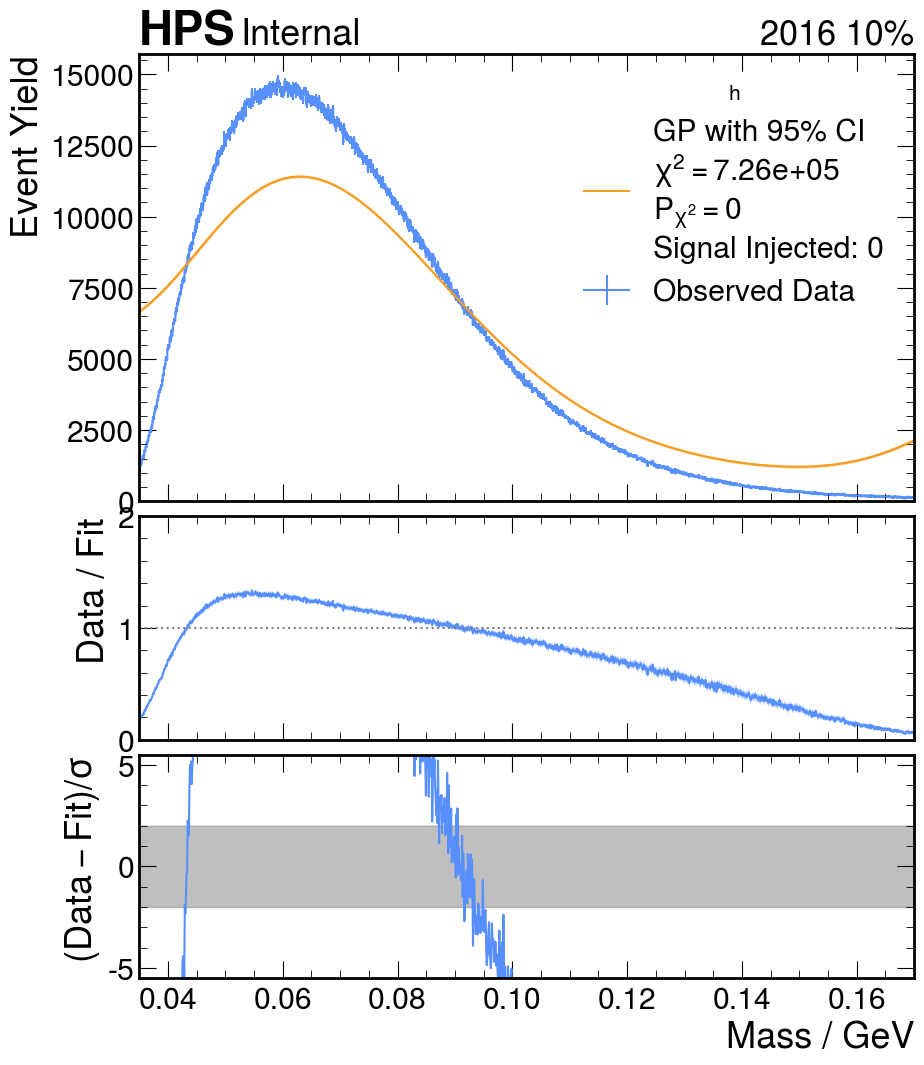

In [40]:

kernel = (
    gp.kernels.ConstantKernel(
        constant_value=1.0,
        constant_value_bounds=(1e-2, 1e2)   # O(0.01–10) in rescaled units
    )
  + gp.kernels.Matern(
        length_scale=0.02,
        length_scale_bounds=(0.01, 0.2),    # wiggles on 10–500 keV
        nu=1.5
    )
  + gp.kernels.WhiteKernel(
        noise_level=1.0,
        noise_level_bounds=(0.1, 100)       # up to O(100) noise
    )
)

m = gp.GaussianProcessModel(
    #h = ('2015.root', 'invariant_mass'),#2015 100%
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    #kernel = gp.kernels.RBF(),
    #kernel = gp.kernels.RationalQuadratic() + gp.kernels.WhiteKernel(noise_level=7e3),
    kernel = kernel,

    n_restarts_optimizer = 20,
    #kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    #blind_range = (mass_hypothesis-2*sig_width(mass_hypothesis, coefficients), mass_hypothesis+2*sig_width(mass_hypothesis, coefficients)),
    #modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.050), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]
    modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin,0.035,0.170)
)

m.model
m.model.kernel_
fig, axes = m.plot_comparison(l=
            '\n'.join([
                'GP with 95% CI',
                f'$\chi^2 = ${m.chi2_statistic:.3g}',
                r'$P_{\chi^2} = $'+f'{m.p_value:.3g}',
                #'Blind Range: ' + str(round(m.blind_range[1]-m.blind_range[0], 5)),
                'Signal Injected: ' + str(events)]),
                             t = 'h')
plt.show()

In [44]:
m.model.kernel_

WhiteKernel(noise_level=6.2e+03) + RBF(length_scale=0.0201) * DotProduct(sigma_0=5.91e+03)

<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\c'
/var/folders/lh/5k1xk47s7q9dgdbf5kby_6_h0000gn/T/ipykernel_73180/1184853916.py:17: SyntaxWarning: invalid escape sequence '\c'
  f'$\chi^2 = ${m.chi2_statistic:.3g}',


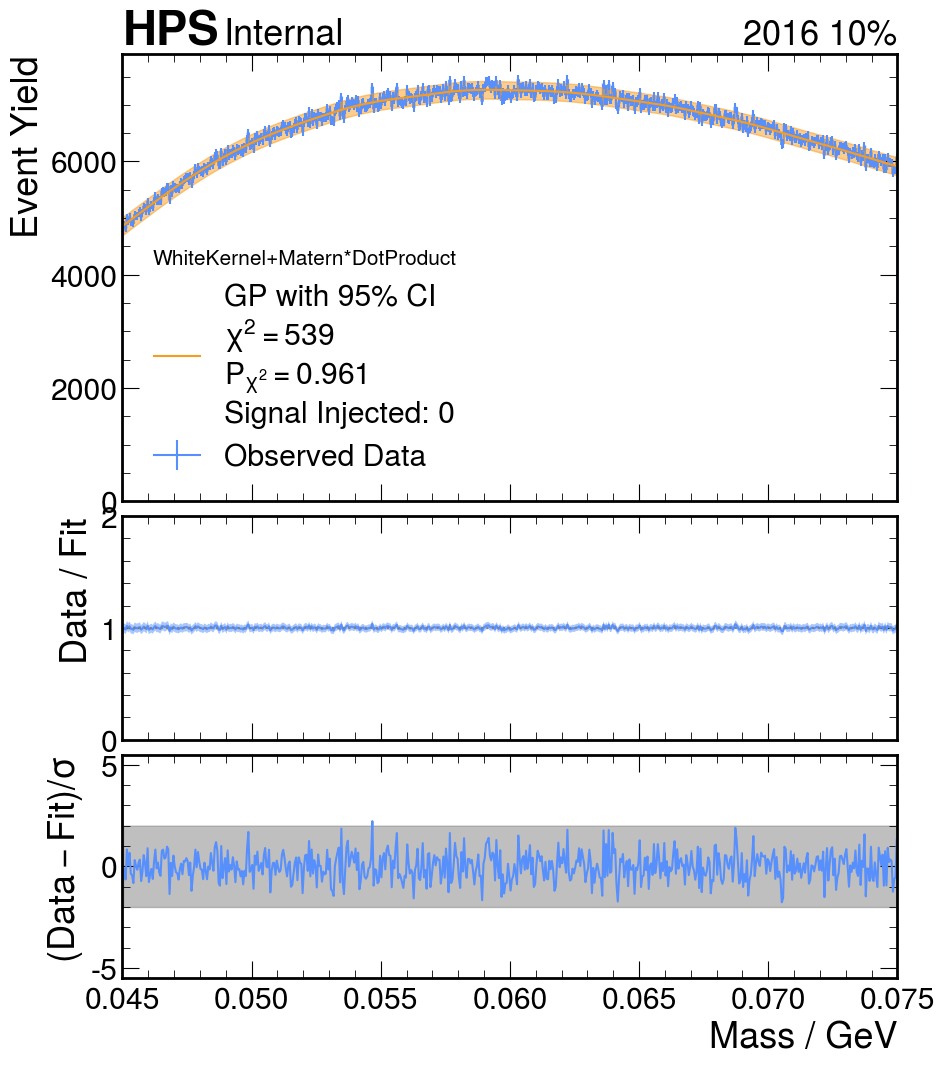

In [48]:
m = gp.GaussianProcessModel(
    #h = ('2015.root', 'invariant_mass'),#2015 100%
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    #kernel = gp.kernels.RBF(),
    #kernel = gp.kernels.RationalQuadratic() + gp.kernels.WhiteKernel(noise_level=7e3),
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.Matern(length_scale=0.02, nu=1.5)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    #blind_range = (mass_hypothesis-2*sig_width(mass_hypothesis, coefficients), mass_hypothesis+2*sig_width(mass_hypothesis, coefficients)),
    #modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.050), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]
    modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin,0.045,0.075)
)

m.model
m.model.kernel_
fig, axes = m.plot_comparison(l=
            '\n'.join([
                'GP with 95% CI',
                f'$\chi^2 = ${m.chi2_statistic:.3g}',
                r'$P_{\chi^2} = $'+f'{m.p_value:.3g}',
                #'Blind Range: ' + str(round(m.blind_range[1]-m.blind_range[0], 5)),
                'Signal Injected: ' + str(events)]),
                             t = 'WhiteKernel+Matern*DotProduct')
plt.show()

In [58]:
m.histogram.axes.centers.

(600,)

<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\c'
/var/folders/lh/5k1xk47s7q9dgdbf5kby_6_h0000gn/T/ipykernel_73180/2191667726.py:17: SyntaxWarning: invalid escape sequence '\c'
  f'$\chi^2 = ${m.chi2_statistic:.3g}',


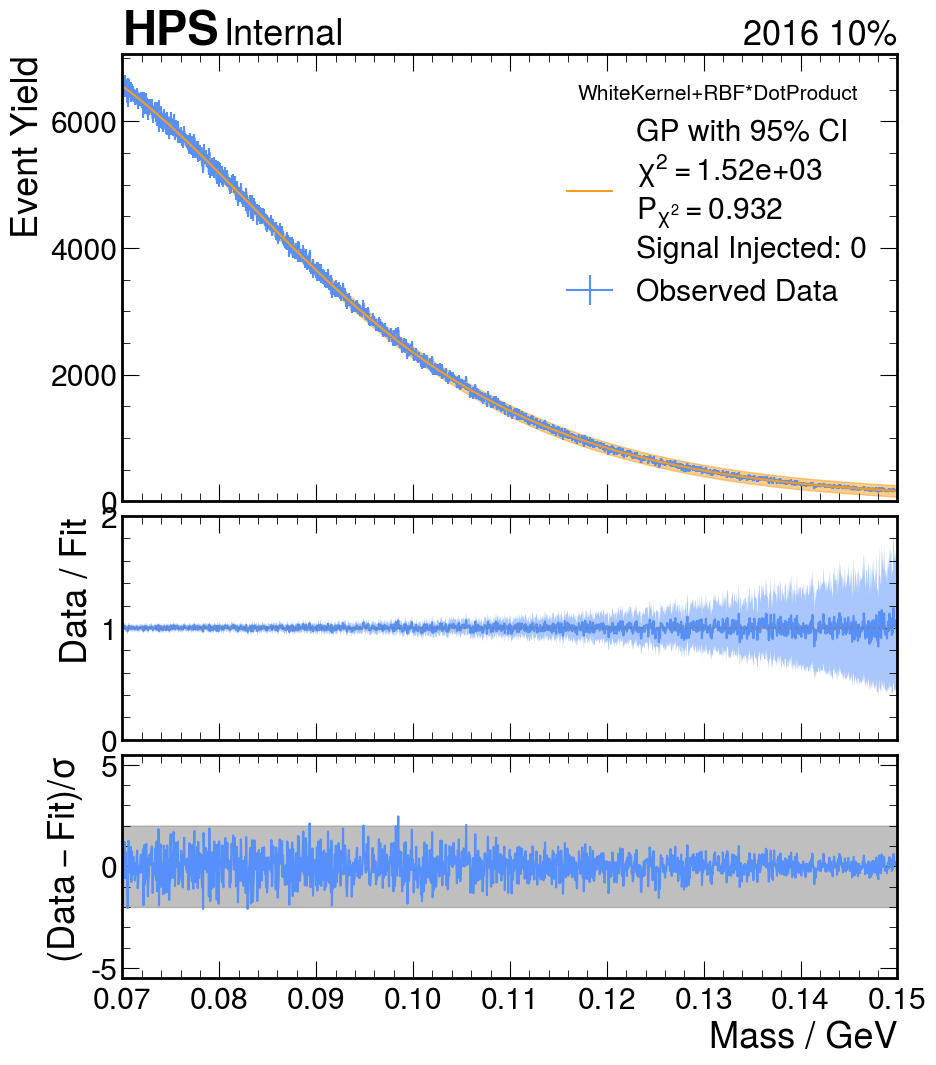

In [61]:
m = gp.GaussianProcessModel(
    #h = ('2015.root', 'invariant_mass'),#2015 100%
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    #kernel = gp.kernels.RBF(),
    #kernel = gp.kernels.RationalQuadratic() + gp.kernels.WhiteKernel(noise_level=7e3),
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    #blind_range = (mass_hypothesis-2*sig_width(mass_hypothesis, coefficients), mass_hypothesis+2*sig_width(mass_hypothesis, coefficients)),
    #modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.050), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]
    modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin,0.070,0.150)
)

m.model
m.model.kernel_
fig, axes = m.plot_comparison(l=
            '\n'.join([
                'GP with 95% CI',
                f'$\chi^2 = ${m.chi2_statistic:.3g}',
                r'$P_{\chi^2} = $'+f'{m.p_value:.3g}',
                #'Blind Range: ' + str(round(m.blind_range[1]-m.blind_range[0], 5)),
                'Signal Injected: ' + str(events)]),
                             t = 'WhiteKernel+RBF*DotProduct')
plt.show()

In [106]:
m.histogram.axes.centers[0][1] - m.histogram.axes.centers[0][2]

np.float64(-4.999999999999449e-05)

In [110]:
m.histogram.axes.widths[0][0]

np.float64(5.000000000000837e-05)